### generate multilabel confusion matrix with data input from excel assessment of results
need to work on staying in python and not excel

In [1]:
pip install -U scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 20.5 MB/s  0:00:00m0:00:0100:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install -U seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [68]:
import numpy as np
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
import seaborn as sns
import pandas as pd



In [204]:
# ground truth
gt_train_rpts = pd.read_excel(io='/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/bondsAllocsJune7.xlsx', sheet_name='ground_truth_train', dtype={'pdfname': str, "gt_source": str, "ES_0_percent": bool, "ES_100_percent": bool, "ES_partial": bool, "number_of_cats": int})
gt_train_df = pd.DataFrame(gt_train_rpts)
gt_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   pdfname         34 non-null     str  
 1   gt_source       34 non-null     str  
 2   ES_0_percent    34 non-null     bool 
 3   ES_100_percent  34 non-null     bool 
 4   ES_partial      34 non-null     bool 
 5   number_of_cats  34 non-null     int64
dtypes: bool(3), int64(1), str(2)
memory usage: 2.5 KB


In [205]:
gt_train_df

,pdfname,gt_source,ES_0_percent,ES_100_percent,ES_partial,number_of_cats
0,Climate_Bond_Framework_of_E1_SUBHOLDING_S_A__i...,alloc data table,False,True,False,0
1,Bci_Sustainable_Financing_Framework,manual,False,False,True,6
2,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,False,False,True,7
3,BTG_Sustainable_Financing_Framework,manual,False,False,True,13
4,CABEI_Green_Bond_Framework,manual,False,False,True,4
5,CADU_GREEN_BOND_FRAMEWORK,manual,True,False,False,0
6,CAFs_GREEN_BOND_FRAMEWORK,manual,False,False,True,6
7,CIFI_Green_Bond_Framework,manual,False,False,True,3
8,EGE_Haina_Green_Securities_Framework,manual,False,True,False,0
9,FS_Green_Bond_Framework_-_July_2021,manual,False,False,True,2


In [206]:
# create y_true based on ES percent cols
ES_percent_true = []
for r in gt_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_true.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_true.append('ES 100%')
    elif r.ES_partial:
        ES_percent_true.append('ES partial')
gt_train_df['ES_percent_true'] = ES_percent_true

In [207]:
gt_train_df

,pdfname,gt_source,ES_0_percent,ES_100_percent,ES_partial,number_of_cats,ES_percent_true
0,Climate_Bond_Framework_of_E1_SUBHOLDING_S_A__i...,alloc data table,False,True,False,0,ES 100%
1,Bci_Sustainable_Financing_Framework,manual,False,False,True,6,ES partial
2,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,False,False,True,7,ES partial
3,BTG_Sustainable_Financing_Framework,manual,False,False,True,13,ES partial
4,CABEI_Green_Bond_Framework,manual,False,False,True,4,ES partial
5,CADU_GREEN_BOND_FRAMEWORK,manual,True,False,False,0,ES 0%
6,CAFs_GREEN_BOND_FRAMEWORK,manual,False,False,True,6,ES partial
7,CIFI_Green_Bond_Framework,manual,False,False,True,3,ES partial
8,EGE_Haina_Green_Securities_Framework,manual,False,True,False,0,ES 100%
9,FS_Green_Bond_Framework_-_July_2021,manual,False,False,True,2,ES partial


In [134]:
# pipeline predictions - V4 sim TH = 0.65
pred_train_rpts = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/pred_train_rpts_V4.csv')
pred_train_df = pd.DataFrame(pred_train_rpts)
pred_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pdfname               34 non-null     str    
 1   nlp_path              34 non-null     str    
 2   language              34 non-null     str    
 3   similarity_threshold  34 non-null     float64
 4   cleanup_threshold     34 non-null     float64
 5   ES_0_percent          34 non-null     bool   
 6   ES_100_percent        34 non-null     bool   
 7   ES_partial            34 non-null     bool   
 8   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(1), str(3)
memory usage: 3.5 KB


In [135]:
# pipeline predictions - V5 sim TH = 0.80
pred_train_rpts_v5 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/pred_train_rpts_V5.csv')
pred_train_df_v5 = pd.DataFrame(pred_train_rpts_v5)
pred_train_df_v5.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pdfname               34 non-null     str    
 1   nlp_path              34 non-null     str    
 2   language              34 non-null     str    
 3   similarity_threshold  34 non-null     float64
 4   cleanup_threshold     34 non-null     float64
 5   ES_0_percent          34 non-null     bool   
 6   ES_100_percent        34 non-null     bool   
 7   ES_partial            34 non-null     bool   
 8   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(1), str(3)
memory usage: 3.5 KB


In [136]:
pred_train_df_v5

,pdfname,nlp_path,language,similarity_threshold,cleanup_threshold,ES_0_percent,ES_100_percent,ES_partial,number_of_cats
0,Bci_Sustainable_Financing_Framework,UOP_section_false,EN,0.8,0.65,False,False,True,6
1,Bono_Azul_-_Framework,UOP_section_true,ES,0.8,0.65,True,False,False,2
2,Bono_Verde_de_Bancoldex_Framework,UOP_section_true,ES,0.8,0.65,False,False,True,7
3,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",Table,EN,0.8,0.65,False,False,True,6
4,BTG_Sustainable_Financing_Framework,UOP_section_true,EN,0.8,0.65,False,False,True,10
5,CABEI_Green_Bond_Framework,Table,EN,0.8,0.65,False,False,True,3
6,CADU_GREEN_BOND_FRAMEWORK,UOP_section_false,EN,0.8,0.65,True,False,False,4
7,CAFs_GREEN_BOND_FRAMEWORK,Table,EN,0.8,0.65,False,False,True,4
8,Cartilla_Bonos_Verdes,UOP_section_true,ES,0.8,0.65,False,False,True,8
9,Chile_Sustainable_Bond_Framework,Table,EN,0.8,0.65,False,False,True,8


In [208]:
# pipeline predictions - V6 sim TH = 0.88 & cleanup TH 0.70
pred_train_rpts_v6 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/pred_train_rpts_V6.csv')
pred_train_df_v6 = pd.DataFrame(pred_train_rpts_v6)
pred_train_df_v6.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pdfname               34 non-null     str    
 1   nlp_path              34 non-null     str    
 2   language              34 non-null     str    
 3   similarity_threshold  34 non-null     float64
 4   cleanup_threshold     34 non-null     float64
 5   ES_0_percent          34 non-null     bool   
 6   ES_100_percent        34 non-null     bool   
 7   ES_partial            34 non-null     bool   
 8   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(1), str(3)
memory usage: 3.5 KB


In [137]:
# create y_pred based on ES percent cols - V4 sim TH = 0.65
ES_percent_pred = []
for r in pred_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df['ES_percent_pred'] = ES_percent_pred


In [138]:
# create y_pred based on ES percent cols - V5 sim TH = 0.80
ES_percent_pred = []
for r in pred_train_df_v5.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df_v5['ES_percent_pred'] = ES_percent_pred

In [209]:
# create y_pred based on ES percent cols - V6 sim TH = 0.88 & cleanup TH 0.70
ES_percent_pred = []
for r in pred_train_df_v6.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df_v6['ES_percent_pred'] = ES_percent_pred

In [139]:
# create a dataset containing results for confusion matrix - V4 sim TH = 0.65

conf_mtrx_df = pd.DataFrame()

conf_mtrx_df['pdfname'] = pred_train_df['pdfname']
conf_mtrx_df['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df['nlp_path'] = pred_train_df['nlp_path']
conf_mtrx_df['language'] = pred_train_df['language']
conf_mtrx_df['similarity_th'] = pred_train_df['similarity_threshold']
conf_mtrx_df['cleanup_th'] = pred_train_df['cleanup_threshold']
conf_mtrx_df['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df['ES_percent_pred'] = pred_train_df['ES_percent_pred']
conf_mtrx_df['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df['num_cats_pred'] = pred_train_df['number_of_cats']
conf_mtrx_df['num_cats_diff'] = conf_mtrx_df['num_cats_true'] - conf_mtrx_df['num_cats_pred']


In [140]:
# create a dataset containing results for confusion matrix - V5 sim TH = 0.80

conf_mtrx_df_v5 = pd.DataFrame()

conf_mtrx_df_v5['pdfname'] = pred_train_df_v5['pdfname']
conf_mtrx_df_v5['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df_v5['nlp_path'] = pred_train_df_v5['nlp_path']
conf_mtrx_df_v5['language'] = pred_train_df_v5['language']
conf_mtrx_df_v5['similarity_th'] = pred_train_df_v5['similarity_threshold']
conf_mtrx_df_v5['cleanup_th'] = pred_train_df_v5['cleanup_threshold']
conf_mtrx_df_v5['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df_v5['ES_percent_pred'] = pred_train_df_v5['ES_percent_pred']
conf_mtrx_df_v5['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df_v5['num_cats_pred'] = pred_train_df_v5['number_of_cats']
conf_mtrx_df_v5['num_cats_diff'] = conf_mtrx_df_v5['num_cats_true'] - conf_mtrx_df_v5['num_cats_pred']

In [210]:
# create a dataset containing results for confusion matrix - V6 sim TH = 0.88 & cleanup TH 0.70

conf_mtrx_df_v6 = pd.DataFrame()

conf_mtrx_df_v6['pdfname'] = pred_train_df_v6['pdfname']
conf_mtrx_df_v6['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df_v6['nlp_path'] = pred_train_df_v6['nlp_path']
conf_mtrx_df_v6['language'] = pred_train_df_v6['language']
conf_mtrx_df_v6['similarity_th'] = pred_train_df_v6['similarity_threshold']
conf_mtrx_df_v6['cleanup_th'] = pred_train_df_v6['cleanup_threshold']
conf_mtrx_df_v6['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df_v6['ES_percent_pred'] = pred_train_df_v6['ES_percent_pred']
conf_mtrx_df_v6['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df_v6['num_cats_pred'] = pred_train_df_v6['number_of_cats']
conf_mtrx_df_v6['num_cats_diff'] = conf_mtrx_df_v6['num_cats_true'] - conf_mtrx_df_v6['num_cats_pred']

In [141]:
conf_mtrx_df

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff
0,Bci_Sustainable_Financing_Framework,manual,UOP_section_false,EN,0.65,0.65,ES partial,ES partial,6,7,-1
1,Bono_Azul_-_Framework,manual,UOP_section_true,ES,0.65,0.65,ES 0%,ES 0%,0,5,-5
2,Bono_Verde_de_Bancoldex_Framework,manual,UOP_section_true,ES,0.65,0.65,ES partial,ES partial,5,10,-5
3,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,Table,EN,0.65,0.65,ES partial,ES partial,7,6,1
4,BTG_Sustainable_Financing_Framework,manual,UOP_section_true,EN,0.65,0.65,ES partial,ES partial,13,10,3
5,CABEI_Green_Bond_Framework,manual,Table,EN,0.65,0.65,ES partial,ES partial,4,3,1
6,CADU_GREEN_BOND_FRAMEWORK,manual,UOP_section_false,EN,0.65,0.65,ES 0%,ES partial,0,7,-7
7,CAFs_GREEN_BOND_FRAMEWORK,manual,Table,EN,0.65,0.65,ES partial,ES partial,6,4,2
8,Cartilla_Bonos_Verdes,manual,UOP_section_true,ES,0.65,0.65,ES partial,ES partial,8,10,-2
9,Chile_Sustainable_Bond_Framework,manual,Table,EN,0.65,0.65,ES partial,ES partial,17,8,9


In [142]:
# create ES Partial TP col based on ES percent cols - V4 sim TH = 0.65
ES_partial_True_Positives = []
for r in conf_mtrx_df.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df['ES_partial_True_Positives'].value_counts()
conf_mtrx_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    34 non-null     str    
 1   gt_source                  34 non-null     str    
 2   nlp_path                   34 non-null     str    
 3   language                   34 non-null     str    
 4   similarity_th              34 non-null     float64
 5   cleanup_th                 34 non-null     float64
 6   ES_percent_true            34 non-null     str    
 7   ES_percent_pred            34 non-null     str    
 8   num_cats_true              34 non-null     int64  
 9   num_cats_pred              34 non-null     int64  
 10  num_cats_diff              34 non-null     int64  
 11  ES_partial_True_Positives  34 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 5.5 KB


In [144]:
# create ES Partial TP col based on ES percent cols - V5 sim TH = 0.80
ES_partial_True_Positives = []
for r in conf_mtrx_df_v5.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df_v5['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df_v5['ES_partial_True_Positives'].value_counts()
conf_mtrx_df_v5.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    34 non-null     str    
 1   gt_source                  34 non-null     str    
 2   nlp_path                   34 non-null     str    
 3   language                   34 non-null     str    
 4   similarity_th              34 non-null     float64
 5   cleanup_th                 34 non-null     float64
 6   ES_percent_true            34 non-null     str    
 7   ES_percent_pred            34 non-null     str    
 8   num_cats_true              34 non-null     int64  
 9   num_cats_pred              34 non-null     int64  
 10  num_cats_diff              34 non-null     int64  
 11  ES_partial_True_Positives  34 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 5.5 KB


In [211]:
# create ES Partial TP col based on ES percent cols - V6 sim TH = 0.88 & cleanup TH 0.70
ES_partial_True_Positives = []
for r in conf_mtrx_df_v6.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df_v6['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df_v6['ES_partial_True_Positives'].value_counts()
conf_mtrx_df_v6.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    34 non-null     str    
 1   gt_source                  34 non-null     str    
 2   nlp_path                   34 non-null     str    
 3   language                   34 non-null     str    
 4   similarity_th              34 non-null     float64
 5   cleanup_th                 34 non-null     float64
 6   ES_percent_true            34 non-null     str    
 7   ES_percent_pred            34 non-null     str    
 8   num_cats_true              34 non-null     int64  
 9   num_cats_pred              34 non-null     int64  
 10  num_cats_diff              34 non-null     int64  
 11  ES_partial_True_Positives  34 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 5.5 KB


In [145]:
# bring in data from eval - V4 sim TH = 0.65

y_true = conf_mtrx_df['ES_percent_true']
y_pred = conf_mtrx_df['ES_percent_pred']
labels = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true, y_pred, labels=labels)

array([[[29,  1],
        [ 3,  1]],

       [[22,  1],
        [ 8,  3]],

       [[ 4, 11],
        [ 2, 17]]])

In [146]:
# bring in data from eval - V5 sim TH = 0.80

y_true_v5 = conf_mtrx_df_v5['ES_percent_true']
y_pred_v5 = conf_mtrx_df_v5['ES_percent_pred']
labels_v5 = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true_v5, y_pred_v5, labels=labels_v5)

array([[[28,  2],
        [ 1,  3]],

       [[23,  0],
        [ 7,  4]],

       [[ 7,  8],
        [ 2, 17]]])

In [212]:
# bring in data from eval - V6 sim TH = 0.88 & cleanup TH 0.70

y_true_v6 = conf_mtrx_df_v6['ES_percent_true']
y_pred_v6 = conf_mtrx_df_v6['ES_percent_pred']
labels_v6 = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true_v6, y_pred_v6, labels=labels_v6)

array([[[27,  3],
        [ 1,  3]],

       [[23,  0],
        [ 6,  5]],

       [[ 8,  7],
        [ 3, 16]]])

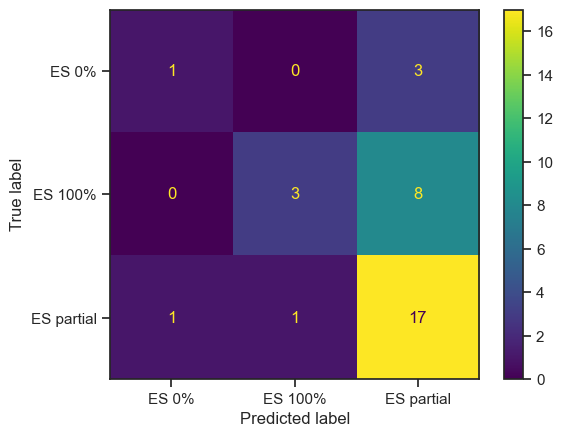

In [147]:
# display confusion matrix - V4 sim TH = 0.65

cm = multilabel_confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

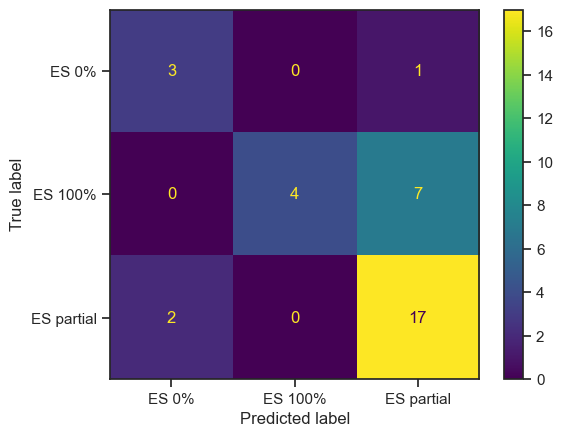

In [148]:
# display confusion matrix - V5 sim TH = 0.80

cm = multilabel_confusion_matrix(y_true_v5, y_pred_v5)
disp = ConfusionMatrixDisplay.from_predictions(y_true_v5, y_pred_v5)
plt.show()


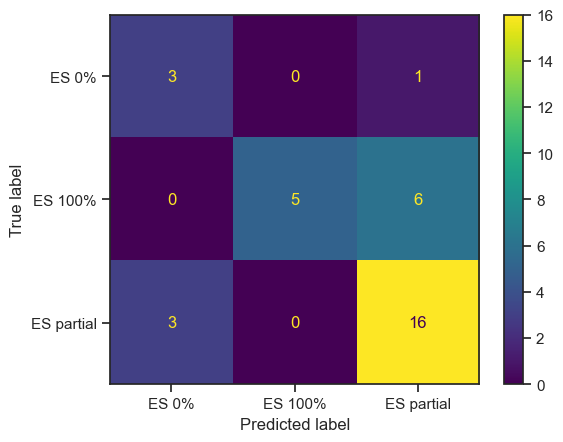

In [213]:
# display confusion matrix - V6 sim TH = 0.88 & cleanup TH 0.70

cm = multilabel_confusion_matrix(y_true_v6, y_pred_v6)
disp = ConfusionMatrixDisplay.from_predictions(y_true_v6, y_pred_v6)
plt.show()

In [ ]:
# breakdown of ES 100% false negatives
# EGE a very good example of limitations of program
# Coop - problem with period in the ESML list. also problem with la and y in green buildings - limitation of program separates la from noun 
# inspect all 10 and cateogorise into limitations of prog and what that is vs fixable
trues = conf_mtrx_df_v5['ES_percent_true'] == 'ES 100%'
preds = conf_mtrx_df_v5['ES_percent_pred'] == 'ES partial'

ES_100_FNs = conf_mtrx_df_v5[trues & preds]
ES_100_FNs



,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
12,EGE_Haina_Green_Securities_Framework,manual,UOP_section_true,EN,0.8,0.65,ES 100%,ES partial,0,4,-4,False
15,Genneia_Green_Bond_Framework,manual,UOP_section_true,EN,0.8,0.65,ES 100%,ES partial,0,2,-2,False
18,Green_Bond_Framework,manual,Table,PT,0.8,0.65,ES 100%,ES partial,0,2,-2,False
20,Green_Bonds_Framework_Athon_2020,alloc data table,UOP_section_true,PT,0.8,0.65,ES 100%,ES partial,0,4,-4,False
23,ILAP_Green_Financing_Framework,manual,UOP_section_false,EN,0.8,0.65,ES 100%,ES partial,0,4,-4,False
26,Marco_de_referencia_de_bono_verde_Coopeguanaca...,manual,UOP_section_true,ES,0.8,0.65,ES 100%,ES partial,0,7,-7,False
30,Nacional_Financiera_Green_Bond_MXN,manual,Table,ES,0.8,0.65,ES 100%,ES partial,0,2,-2,False


In [159]:
# pipeline predictions - V5 sim TH = 0.80
UOP_Words_csv_v5 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/UOP_Words_csv_v5.csv')
UOP_Words_csv_v5 = pd.DataFrame(UOP_Words_csv_v5)
UOP_Words_csv_v5.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 22 columns):
 #   Column                                                                           Non-Null Count  Dtype
---  ------                                                                           --------------  -----
 0   pdfname                                                                          19 non-null     str  
 1   energy_system_uop                                                                19 non-null     bool 
 2   renewable_energy                                                                 19 non-null     str  
 3   re_scores                                                                        19 non-null     str  
 4   energy_efficiency                                                                19 non-null     str  
 5   ee_scores                                                                        19 non-null     str  
 6   pollution_prevention_and_control       

In [160]:
UOP_Words_csv_v5

,pdfname,energy_system_uop,renewable_energy,re_scores,energy_efficiency,ee_scores,pollution_prevention_and_control,ppc_scores,environmentally_sustainable_management_of_living_natural_resources_and_land_use,esml_scores,...,clean_transportation,ct_scores,sustainable_water_and_wastewater_management,swwm_scores,climate_change_adaptation,cca_scores,circular_economy_and_or_ecoefficient_projects,ce_scores,green_buildings,gb_scores
0,Bci_Sustainable_Financing_Framework,True,"dict_keys(['generation generation', 'power pow...","dict_values([1.0, 0.8561059832572937, 1.0, 1.0...",dict_keys(['efficiency efficiency']),dict_values([1.0]),dict_keys(['waste waste']),dict_values([1.0]),dict_keys([]),dict_values([]),...,"dict_keys(['electric electric', 'vehicle vehic...","dict_values([1.0, 0.8584986925125122, 1.0, 1.0])","dict_keys(['water water', 'potable potable', '...","dict_values([1.0, 1.0, 1.0, 1.0])",dict_keys([]),dict_values([]),dict_keys([]),dict_values([]),dict_keys(['buildings buildings']),dict_values([1.0])
1,Bono_Azul_-_Framework,False,dict_keys([]),dict_values([]),dict_keys([]),dict_values([]),dict_keys(['de de']),dict_values([0.9079835414886475]),dict_keys([]),dict_values([]),...,dict_keys([]),dict_values([]),dict_keys([]),dict_values([]),dict_keys([]),dict_values([]),dict_keys([]),dict_values([]),dict_keys(['y y']),dict_values([0.9070735573768616])
2,Bono_Verde_de_Bancoldex_Framework,True,dict_keys(['hidroelectricidad hidroeléctricas'...,"dict_values([0.8153160214424133, 1.0, 0.819848...",dict_keys([]),dict_values([]),"dict_keys(['de de', 'contaminación contaminaci...","dict_values([0.9079835414886475, 1.0, 0.856733...","dict_keys(['. residual', '. económicos', '. ed...","dict_values([0.9217485785484314, 0.85856795310...",...,"dict_keys(['la la', 'transporte transporte', '...","dict_values([0.939012348651886, 1.0, 1.0])",dict_keys([]),dict_values([]),"dict_keys(['adecuación adecuaciones', 'adecuac...","dict_values([0.806394100189209, 0.862111866474...",dict_keys([]),dict_values([]),"dict_keys(['la la', 'construcciones adecuacion...","dict_values([0.947020411491394, 0.813196659088..."
3,BTG_Sustainable_Financing_Framework,True,"dict_keys(['grid grid', 'renewable renewable',...","dict_values([0.8128994703292847, 1.0, 1.0, 1.0...",dict_keys(['efficiency efficiency']),dict_values([1.0]),"dict_keys(['pollution pollution', 'waste waste'])","dict_values([1.0, 1.0])","dict_keys(['food food', 'agriculture agricultu...","dict_values([1.0, 1.0, 0.898859441280365, 0.84...",...,"dict_keys(['rail rail', 'electric electric', '...","dict_values([1.0, 0.8524656295776367, 0.858498...","dict_keys(['wastewater wastewater', 'water wat...","dict_values([1.0, 0.8583021759986877, 0.829557...","dict_keys(['adaptation adaptation', 'disaster ...","dict_values([1.0, 0.8176723718643188])",dict_keys(['recycle recycling']),dict_values([0.8278464674949646]),"dict_keys(['housing housing', 'buildings build...","dict_values([1.0, 0.8454830050468445])"
4,CADU_GREEN_BOND_FRAMEWORK,False,dict_keys([]),dict_values([]),dict_keys(['efficiency efficiency']),dict_values([1.0]),dict_keys(['waste waste']),dict_values([1.0]),dict_keys([]),dict_values([]),...,dict_keys([]),dict_values([]),"dict_keys(['water water', 'wastewater sewage'])","dict_values([0.8583021759986877, 0.86581504344...",dict_keys([]),dict_values([]),dict_keys([]),dict_values([]),"dict_keys(['buildings buildings', 'housing hou...","dict_values([1.0, 1.0])"
5,Cartilla_Bonos_Verdes,True,"dict_keys(['biocombustible combustible', 'gene...","dict_values([0.8335129022598267, 1.0, 0.819848...",dict_keys([]),dict_values([]),dict_keys(['de de']),dict_values([0.9079835414886475]),"dict_keys(['. saneamiento', '. orgánicos', '. ...","dict_values([0.8664849996566772, 0.87855154275...",...,"dict_keys(['la la', 'transporte transporte', '...","dict_values([0.939012348651886, 1.0, 0.9680165...","dict_keys(['saneamiento mantenimiento', ' pot...","dict_values([0.8064507842063904, 1.00000011920...","dict_keys(['adecuación evalu

In [162]:
UOP_Words_csv_v5.iloc[14].loc['environmentally_sustainable_management_of_living_natural_resources_and_land_use']

"dict_keys(['. r.l', '. valorizables', '. fiscalizaciones', '. construcción', '. huacas', '. otorgados', '. favorable'])"

In [150]:
# accuracy metrix - V4 sim TH = 0.65

accuracy_score_frac = accuracy_score(y_true, y_pred)
accuracy_score_num = accuracy_score(y_true, y_pred, normalize=False)

print(accuracy_score_frac, accuracy_score_num)

f1 = f1_score(y_true, y_pred, average='macro')
print(f1)

0.6176470588235294 21.0
0.48557919621749407


In [151]:
# accuracy metrix - V5 sim TH = 0.80

accuracy_score_frac_v5 = accuracy_score(y_true_v5, y_pred_v5)
accuracy_score_num_v5 = accuracy_score(y_true_v5, y_pred_v5, normalize=False)

print(accuracy_score_frac_v5, accuracy_score_num_v5)

f1_v5 = f1_score(y_true_v5, y_pred_v5, average='macro')
print(f1_v5)

0.7058823529411765 24.0
0.6575757575757576


In [214]:
# accuracy metrix - V6 sim TH = 0.88 & cleanup TH 0.70

accuracy_score_frac_v6 = accuracy_score(y_true_v6, y_pred_v6)
accuracy_score_num_v6 = accuracy_score(y_true_v6, y_pred_v6, normalize=False)

print(accuracy_score_frac_v6, accuracy_score_num_v6)

f1_v6 = f1_score(y_true_v6, y_pred_v6, average='macro')
print(f1_v6)

0.7058823529411765 24.0
0.6623015873015873


In [152]:
# create a dataset containing results for boxplots - V4 sim TH = 0.65

boxplot_df = conf_mtrx_df.query("ES_partial_True_Positives == True")
boxplot_df.info()


<class 'pandas.DataFrame'>
Index: 17 entries, 0 to 32
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    17 non-null     str    
 1   gt_source                  17 non-null     str    
 2   nlp_path                   17 non-null     str    
 3   language                   17 non-null     str    
 4   similarity_th              17 non-null     float64
 5   cleanup_th                 17 non-null     float64
 6   ES_percent_true            17 non-null     str    
 7   ES_percent_pred            17 non-null     str    
 8   num_cats_true              17 non-null     int64  
 9   num_cats_pred              17 non-null     int64  
 10  num_cats_diff              17 non-null     int64  
 11  ES_partial_True_Positives  17 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.9 KB


In [153]:
# create a dataset containing results for boxplots - V5 sim TH = 0.80

boxplot_df_v5 = conf_mtrx_df_v5.query("ES_partial_True_Positives == True")
boxplot_df_v5.info()

<class 'pandas.DataFrame'>
Index: 17 entries, 0 to 32
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    17 non-null     str    
 1   gt_source                  17 non-null     str    
 2   nlp_path                   17 non-null     str    
 3   language                   17 non-null     str    
 4   similarity_th              17 non-null     float64
 5   cleanup_th                 17 non-null     float64
 6   ES_percent_true            17 non-null     str    
 7   ES_percent_pred            17 non-null     str    
 8   num_cats_true              17 non-null     int64  
 9   num_cats_pred              17 non-null     int64  
 10  num_cats_diff              17 non-null     int64  
 11  ES_partial_True_Positives  17 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.9 KB


In [215]:
# create a dataset containing results for boxplots - V6 sim TH = 0.88 & cleanup TH 0.70

boxplot_df_v6 = conf_mtrx_df_v6.query("ES_partial_True_Positives == True")
boxplot_df_v6.info()

<class 'pandas.DataFrame'>
Index: 16 entries, 1 to 29
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    16 non-null     str    
 1   gt_source                  16 non-null     str    
 2   nlp_path                   16 non-null     str    
 3   language                   16 non-null     str    
 4   similarity_th              16 non-null     float64
 5   cleanup_th                 16 non-null     float64
 6   ES_percent_true            16 non-null     str    
 7   ES_percent_pred            16 non-null     str    
 8   num_cats_true              16 non-null     int64  
 9   num_cats_pred              16 non-null     int64  
 10  num_cats_diff              16 non-null     int64  
 11  ES_partial_True_Positives  16 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.7 KB


<Axes: xlabel='num_cats_diff'>

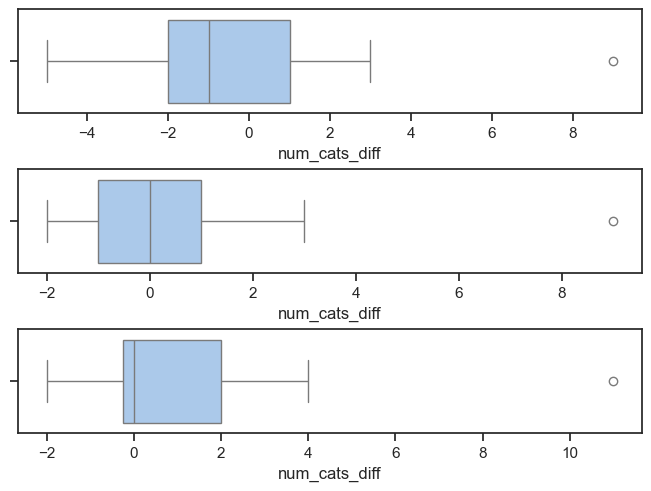

In [ ]:
# boxplots of diff in number of cats - V4 sim TH = 0.65, V5 sim = 0.80 and V6 sim TH = 0.88 & cleanup TH 0.70

fig, axes = plt.subplots(3,1, layout = 'constrained')
sns.set_theme(style='ticks', palette = 'pastel')
sns.boxplot(x=boxplot_df['num_cats_diff'], ax=axes[0])
sns.boxplot(x=boxplot_df_v5['num_cats_diff'], ax=axes[1])
sns.boxplot(x=boxplot_df_v6['num_cats_diff'], ax=axes[2])


<Axes: xlabel='num_cats_diff', ylabel='language'>

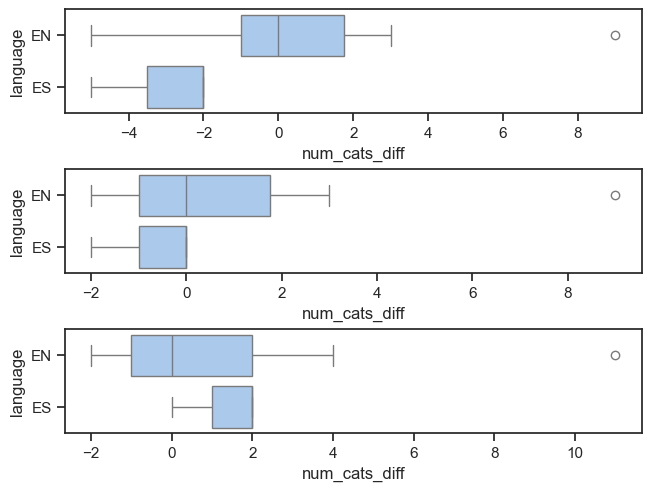

In [219]:
# boxplots of diff in number of cats - V4 sim TH = 0.65, V5 sim = 0.80 and V6 sim TH = 0.88 & cleanup TH 0.70

fig, axes = plt.subplots(3,1, layout = 'constrained')
sns.set_theme(style='ticks', palette = 'pastel')
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['language'], ax=axes[0])
sns.boxplot(x=boxplot_df_v5['num_cats_diff'], y = boxplot_df_v5['language'], ax=axes[1])
sns.boxplot(x=boxplot_df_v6['num_cats_diff'], y = boxplot_df_v6['language'], ax=axes[2])


<Axes: xlabel='num_cats_diff', ylabel='nlp_path'>

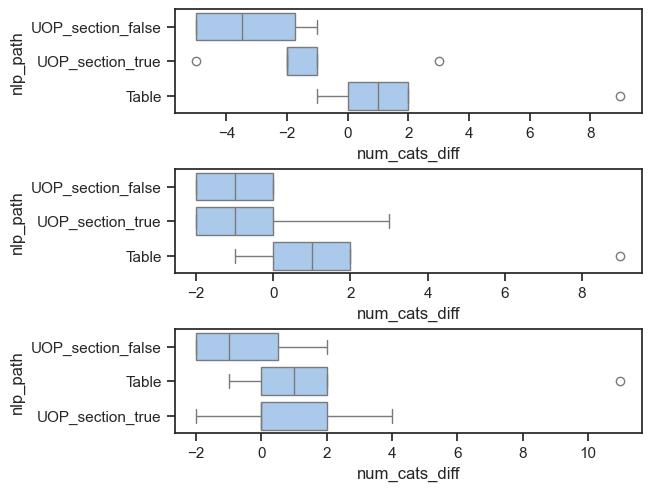

In [220]:
# boxplots of diff in number of cats - V4 sim TH = 0.65, V5 sim = 0.80 and V6 sim TH = 0.88 & cleanup TH 0.70

fig, axes = plt.subplots(3,1, layout = 'constrained')
sns.set_theme(style='ticks', palette = 'pastel')
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['nlp_path'], ax=axes[0])
sns.boxplot(x=boxplot_df_v5['num_cats_diff'], y = boxplot_df_v5['nlp_path'], ax=axes[1])
sns.boxplot(x=boxplot_df_v6['num_cats_diff'], y = boxplot_df_v6['nlp_path'], ax=axes[2])

In [168]:
boxplot_df

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
0,Bci_Sustainable_Financing_Framework,manual,UOP_section_false,EN,0.65,0.65,ES partial,ES partial,6,7,-1,True
2,Bono_Verde_de_Bancoldex_Framework,manual,UOP_section_true,ES,0.65,0.65,ES partial,ES partial,5,10,-5,True
3,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,Table,EN,0.65,0.65,ES partial,ES partial,7,6,1,True
4,BTG_Sustainable_Financing_Framework,manual,UOP_section_true,EN,0.65,0.65,ES partial,ES partial,13,10,3,True
5,CABEI_Green_Bond_Framework,manual,Table,EN,0.65,0.65,ES partial,ES partial,4,3,1,True
7,CAFs_GREEN_BOND_FRAMEWORK,manual,Table,EN,0.65,0.65,ES partial,ES partial,6,4,2,True
8,Cartilla_Bonos_Verdes,manual,UOP_section_true,ES,0.65,0.65,ES partial,ES partial,8,10,-2,True
9,Chile_Sustainable_Bond_Framework,manual,Table,EN,0.65,0.65,ES partial,ES partial,17,8,9,True
10,CIFI_Green_Bond_Framework,manual,UOP_section_true,EN,0.65,0.65,ES partial,ES partial,3,4,-1,True
13,FS_Green_Bond_Framework_-_July_2021,manual,UOP_section_false,EN,0.65,0.65,ES partial,ES partial,2,7,-5,True


In [167]:
boxplot_df_v5

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
0,Bci_Sustainable_Financing_Framework,manual,UOP_section_false,EN,0.8,0.65,ES partial,ES partial,6,6,0,True
2,Bono_Verde_de_Bancoldex_Framework,manual,UOP_section_true,ES,0.8,0.65,ES partial,ES partial,5,7,-2,True
3,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,Table,EN,0.8,0.65,ES partial,ES partial,7,6,1,True
4,BTG_Sustainable_Financing_Framework,manual,UOP_section_true,EN,0.8,0.65,ES partial,ES partial,13,10,3,True
5,CABEI_Green_Bond_Framework,manual,Table,EN,0.8,0.65,ES partial,ES partial,4,3,1,True
7,CAFs_GREEN_BOND_FRAMEWORK,manual,Table,EN,0.8,0.65,ES partial,ES partial,6,4,2,True
8,Cartilla_Bonos_Verdes,manual,UOP_section_true,ES,0.8,0.65,ES partial,ES partial,8,8,0,True
9,Chile_Sustainable_Bond_Framework,manual,Table,EN,0.8,0.65,ES partial,ES partial,17,8,9,True
10,CIFI_Green_Bond_Framework,manual,UOP_section_true,EN,0.8,0.65,ES partial,ES partial,3,4,-1,True
13,FS_Green_Bond_Framework_-_July_2021,manual,UOP_section_false,EN,0.8,0.65,ES partial,ES partial,2,4,-2,True


In [217]:
boxplot_df_v6

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
1,Bci_Sustainable_Financing_Framework,manual,UOP_section_false,EN,0.88,0.7,ES partial,ES partial,6,6,0,True
2,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,Table,EN,0.88,0.7,ES partial,ES partial,7,5,2,True
3,BTG_Sustainable_Financing_Framework,manual,UOP_section_true,EN,0.88,0.7,ES partial,ES partial,13,9,4,True
4,CABEI_Green_Bond_Framework,manual,Table,EN,0.88,0.7,ES partial,ES partial,4,3,1,True
7,CIFI_Green_Bond_Framework,manual,UOP_section_true,EN,0.88,0.7,ES partial,ES partial,3,3,0,True
9,FS_Green_Bond_Framework_-_July_2021,manual,UOP_section_false,EN,0.88,0.7,ES partial,ES partial,2,4,-2,True
10,FS_Green_Bond_Framework_-_November_2020,manual,UOP_section_false,EN,0.88,0.7,ES partial,ES partial,2,4,-2,True
13,Green_Bond_Framework_of_Banco_Guayaquil,manual,Table,EN,0.88,0.7,ES partial,ES partial,4,2,2,True
14,Green_Finance_Framework_Interchile,manual,Table,EN,0.88,0.7,ES partial,ES partial,2,3,-1,True
17,ISA_CTM_FRAMEWORK,manual,Table,EN,0.88,0.7,ES partial,ES partial,2,2,0,True


In [177]:
# pipeline predictions - V5 sim TH = 0.80
table_csv_v5 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/table_csv_v5.csv')
table_csv_v5 = pd.DataFrame(table_csv_v5)
table_csv_v5.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Unnamed: 0                        15 non-null     int64
 1   pdfname                           15 non-null     str  
 2   tablePages_list                   15 non-null     str  
 3   table.Headers_list                15 non-null     str  
 4   countCat_words                    15 non-null     int64
 5   unique compliant Categories_list  15 non-null     str  
 6   energy_system_tbl                 15 non-null     bool 
 7   table_idx_list                    15 non-null     str  
 8   unique Cats all                   15 non-null     str  
 9   simScores for cleanup             15 non-null     str  
 10  simScores for ES                  15 non-null     str  
dtypes: bool(1), int64(2), str(8)
memory usage: 44.1 KB


In [ ]:
# inspect the following index rows for non green cats in unique compliance cats: 4, 2, 3, 9, 7, 8, 1, 5 - the manual FGTs may erroneously include non green - correct manual to green
# why are there EStbl False in the df below?: 13, 6, 0 - 6 an 0 are non ES, 13 - need to understand why th resimScore dict isn't getting generated

# after fixing above , # inspect remaining diffs and cateogorise into limitations of prog and what that is vs fixable
# only item 9 has social and it's access to housing - limitation of prog
table_csv_v5.iloc[9].loc['unique compliant Categories_list']
#selection['unique compliant Categories_list'].to_list

"['energy efficiency', 'access to basic housing', 'renewable energy', 'access to affordable housing', 'green buildings (ecological buildings)', 'natural resources, use of land and protected marine areas', 'food security', 'water management']"

In [199]:
table_csv_v5

,Unnamed: 0,pdfname,tablePages_list,table.Headers_list,countCat_words,unique compliant Categories_list,energy_system_tbl,table_idx_list,unique Cats all,simScores for cleanup,simScores for ES
0,0,Green_social_bond_framework_series_ad_ae_2019,"[3, 6, 7]","[['Category', 'Project name', 'Goal'], ['Categ...",2,"['potable water supply', 'sanitation']",False,"[0, 0, 0, 1, 1, 1]","['potable water supply', 'sanitation', 'resili...",0\npotabl...,Empty DataFrame\nColumns: []\nIndex: []
1,1,ISA_CTM_FRAMEWORK,"[4, 5, 7, 8, 9, 15, 16, 17, 18]","[['Eligible Project Category', 'Questions', 'A...",2,"['energy efficiency', 'renewable energy']",True,"[0, 0]","['energy efficiency', 'renewable energy']",0\nenergy...,0\nrenewable 1.0
2,2,CABEI_Green_Bond_Framework,"[7, 8, 9, 10, 12]","[['Eligible\nGreen\nProjects\nCategories', 'Su...",3,"['renewable energy', 'sustainable land use', '...",True,"[0, 4, 4, 4, 4]","['clean transport', 'renewable energy', 'susta...",0\nrenewabl...,0\nrenewable 1.0
3,3,CAFs_GREEN_BOND_FRAMEWORK,"[1, 2, 8, 9]","[['Measure of Units', 'Col1'], ['Graphics', 'C...",4,"['clean transportation', 'renewable energy', '...",True,"[2, 2, 2, 2]","['clean transportation', 'renewable energy', '...",...,0\nrenewable 1.0
4,4,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...","[15, 16, 17, 19]","[['Green\nProject\nCategory', 'Use of\nProceed...",6,"['clean transportation', 'sustainable water an...",True,"[0, 1, 1, 1, 1, 2, 2, 3, 3, 3, 3, 3, 3, 3]","['clean transportation', 'sustainable water an...",...,0\nrenewable 1.0
5,5,Sicredi_Green_Bond_Framework,"[4, 6]","[['Eligible\nCategories', 'Description', 'Obje...",2,"['energy efficiency', 'renewable energy']",True,"[0, 0]","['energy efficiency', 'renewable energy']",0\nenergy...,0\nrenewable 1.0
6,6,Green_Bond_Financing_Framework,"[7, 8, 10]",[['Eligible Category aligned\nwith ICMA Green ...,2,"['clean transportation', 'energy efficiency']",False,"[0, 2, 2]","['clean transportation', 'energy efficiency']",0\...,Empty DataFrame\nColumns: []\nIndex: []
7,7,Green_Bond_Framework_of_Banco_Guayaquil,"[6, 7, 8, 9, 10, 18, 19, 29, 30, 31, 38, 39]","[['GBP Eligible\nGreen Assets\nCategory', 'Ban...",2,"['energy efficiency', 'renewable energy']",True,"[0, 1, 1, 1, 1]","['energy efficiency', 'renewable energy']",0\nenergy...,0\nrenewable 1.0
8,8,Green_Finance_Framework_Interchile,[8],"[['Eligible Project Category', 'Questions', 'A...",3,"['energy efficiency', 'renewable energy', 'cli...",True,"[0, 0, 0]","['renewable energy', 'energy efficiency', 'cli...",0...,0\nrenewable 1.0
9,9,Chile_Sustainable_Bond_Framework,"[0, 19, 20, 21, 22, 23, 24, 25, 26, 30, 37, 38...","[['Col0', 'Ministry of\nFinance\nGovernment of...",8,"['energy efficiency', 'access to basic housing...",True,"[5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 10, 10, 10, ...",['support for the community through job creati...,...,0\nrenewable 1.0


In [203]:
table_csv_v5.iloc[13].loc['unique Cats all']

"['verdes', 'energías renovables', 'eficiencia energética49 50']"

In [163]:
# stats - whole dataset and ES partial TPs - V4 sim TH = 0.65

#print(conf_mtrx_df['num_cats_true'].describe())
#print(conf_mtrx_df['num_cats_diff'].describe())
print(boxplot_df['num_cats_true'].describe())
print(boxplot_df['num_cats_diff'].describe())

count    17.000000
mean      5.823529
std       4.186814
min       2.000000
25%       2.000000
50%       5.000000
75%       8.000000
max      17.000000
Name: num_cats_true, dtype: float64
count    17.000000
mean     -0.352941
std       3.426755
min      -5.000000
25%      -2.000000
50%      -1.000000
75%       1.000000
max       9.000000
Name: num_cats_diff, dtype: float64


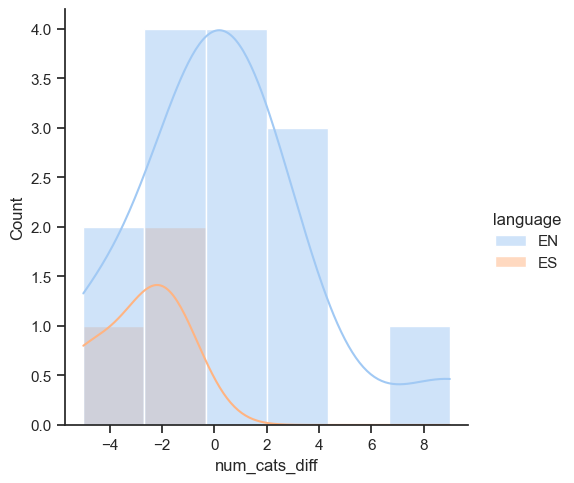

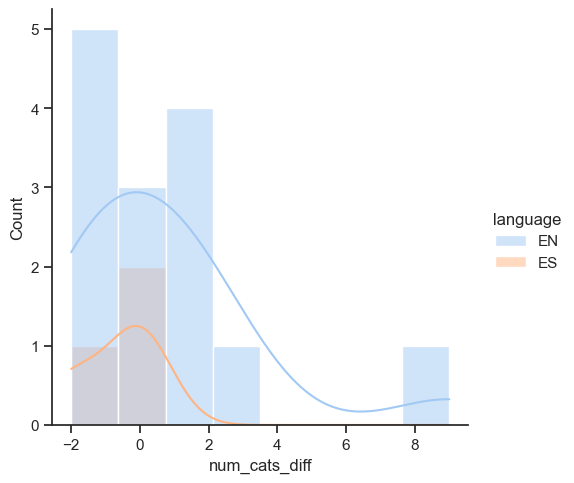

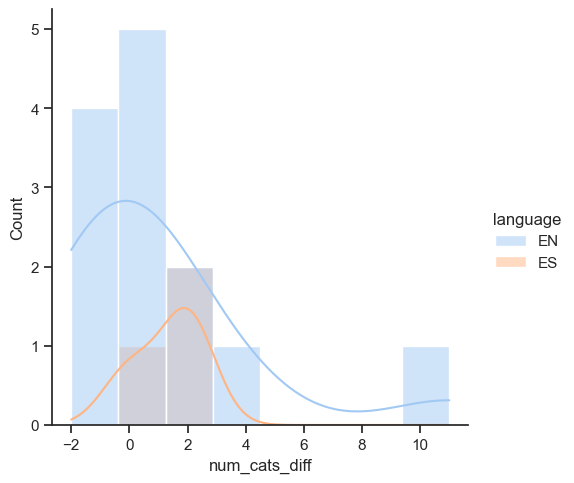

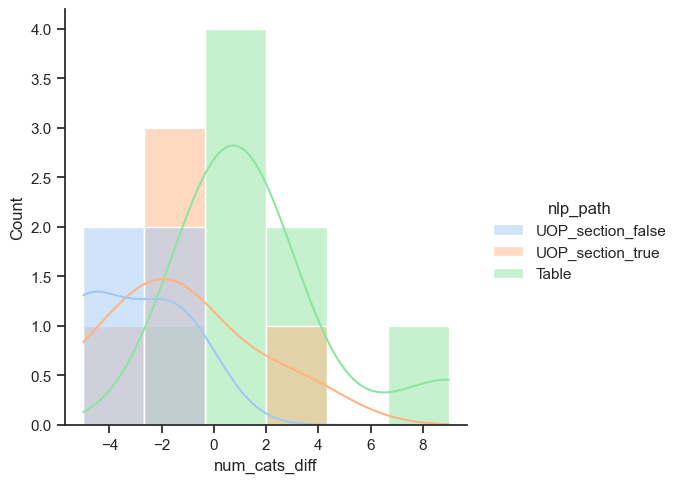

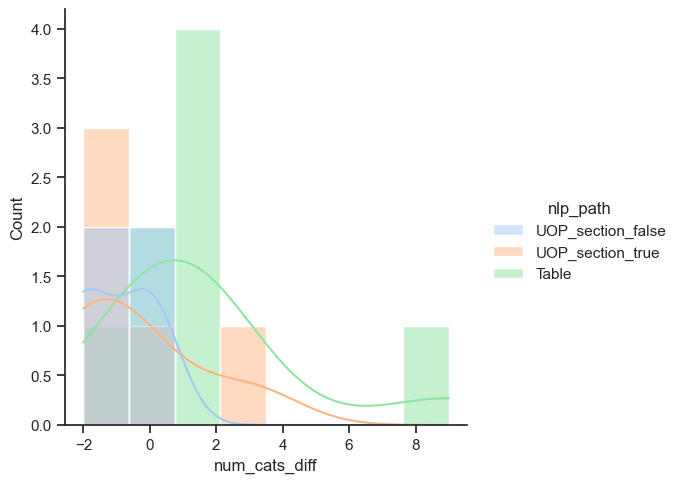

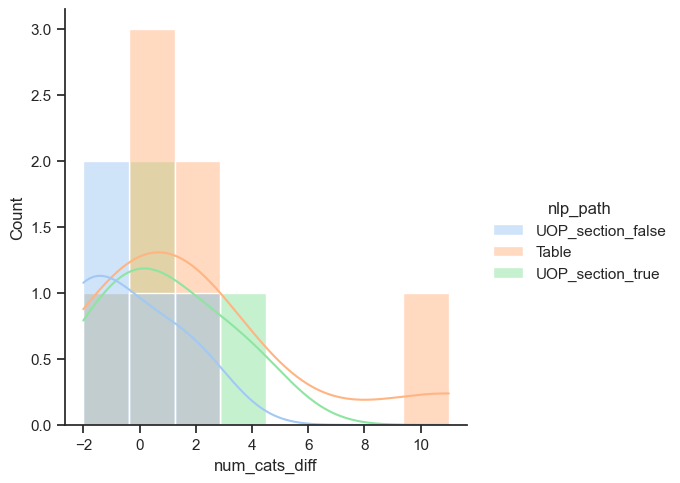

In [218]:
# breakdown of 

sns.displot(boxplot_df, x='num_cats_diff', hue= 'language', kde=True)
sns.displot(boxplot_df_v5, x='num_cats_diff', hue = 'language', kde=True)
sns.displot(boxplot_df_v6, x='num_cats_diff', hue = 'language', kde=True)
sns.displot(boxplot_df, x='num_cats_diff', hue= 'nlp_path', kde=True)
sns.displot(boxplot_df_v5, x='num_cats_diff', hue = 'nlp_path', kde=True)
sns.displot(boxplot_df_v6, x='num_cats_diff', hue = 'nlp_path', kde=True)


In [164]:
# stats - whole dataset and ES partial TPs - V5 sim TH = 0.80

#print(conf_mtrx_df_v5['num_cats_true'].describe())
#print(conf_mtrx_df_v5['num_cats_diff'].describe())
print(boxplot_df_v5['num_cats_true'].describe())
print(boxplot_df_v5['num_cats_diff'].describe())

count    17.000000
mean      5.823529
std       4.186814
min       2.000000
25%       2.000000
50%       5.000000
75%       8.000000
max      17.000000
Name: num_cats_true, dtype: float64
count    17.000000
mean      0.470588
std       2.672023
min      -2.000000
25%      -1.000000
50%       0.000000
75%       1.000000
max       9.000000
Name: num_cats_diff, dtype: float64
